<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 08 - Ejemplo 2 - Regresión lineal
        </td>
    </tr>
    <tr>
 

</table>

### Ejercicio 1:

En este ejercicio se pretende reforzar el manejo de los modelos de regresión lineal simple y profundizar en el análisis del conjunto de datos California Housing.

Se debe cargar el dataset California Housing, previamente analizado en temas anteriores, y construir modelos de regresión lineal simple donde la variable respuesta sea la mediana del valor de las viviendas (`median_house_value`). El análisis debe realizarse utilizando cada una de las variables numéricas del dataset como variable explicativa.

Finalmente, se debe responder la siguiente pregunta: Si únicamente se pudiera seleccionar una variable para predecir el valor mediano de las viviendas del barrio (`median_house_value`), ¿cuál sería la variable más adecuada según los resultados obtenidos?

In [1]:
#Cargar las librerías
import pandas as pd
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import os
import tarfile
import urllib.request
import pandas as pd

In [3]:
#Definir las rutas y caminos donde se encuentran los datos
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
#Path que se va a crear en nuestro sistema-
HOUSING_PATH = os.path.join("datasets", "housing")
# lugar de descarga del dataset
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

#Definir una funcion que obtenga los datos y los descargue
def fetch_housing_data(housing_url=HOUSING_URL, 
housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
fetch_housing_data()

#definir una funcion que cargue el csv en un dataframe
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)
    
housing = load_housing_data()

C:\Users\Michelle Jiménez\AppData\Local\Temp\ipykernel_12824\477940341.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.


In [4]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


A continuación se realiza el ajuste de un modelo de regresión para cada una de las
variables numéricas del dataset con la variable respuesta median_house_value

In [5]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


En el conjunto de datos utilizado existen valores faltantes (NA), una situación muy común al trabajar con datos del mundo real. Ante este tipo de casos es importante analizar las posibles causas de la ausencia de datos y, dependiendo de su origen, decidir si es más apropiado imputar los valores faltantes o eliminar las observaciones incompletas.

Para este ejercicio, se optará por eliminar las observaciones que contengan valores faltantes. Esto implica eliminar todas las filas del conjunto de datos que presenten al menos un valor NA.

Para realizar esta operación se utilizará el método `.dropna()` aplicado al *dataframe*. En el argumento `axis` se debe indicar que la eliminación se realizará por filas (`axis = 0`), eliminando así todas las observaciones que contengan algún valor faltante.

In [7]:
housing_2 = housing.dropna(axis=0, how='any') #Eliminar valores faltantes
housing_2.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [10]:
#Seleccionar variables numéricas
vars_x = ["longitude","latitude","housing_median_age", "total_rooms","total_bedrooms","population","households","median_income"]

y = housing_2["median_house_value"].values.reshape(-1,1) #Seleccionar variable predictora

for var in vars_x:
    x = housing_2[var].values.reshape(-1,1)
    lm = linear_model.LinearRegression()
    lm.fit(x, y)
    y_pred = lm.predict(x)
    r2 = r2_score(y,y_pred)
    print("El r2 de la variable %s es %s" %(var, r2))

El r2 de la variable longitude es 0.002060998318738405
El r2 de la variable latitude es 0.020920212247964698
El r2 de la variable housing_median_age es 0.011327780602248039
El r2 de la variable total_rooms es 0.01776732637429934
El r2 de la variable total_bedrooms es 0.0024687165075718553
El r2 de la variable population es 0.0006400764538163628
El r2 de la variable households es 0.004211172765169913
El r2 de la variable median_income es 0.47383326039767104


Se observa que el coeficiente de determinación de la última variable es mucho mejor que todos los anteriores
calculados. Así pues, si tuviesemos que escoger una única variable para realizar un
modelo de regresión lineal simple, escogeríamos la variable median_income

### Ejercicio 2

Con el objetivo de profundizar en la relación entre las variables `median_house_value` (valor mediano de las viviendas) y **`median_income`** (ingreso mediano del barrio), se propone ajustar un modelo de regresión lineal simple utilizando `median_income` como variable explicativa y `median_house_value` como variable respuesta.

A partir del ajuste del modelo, se solicita:

a) Determinar la ecuación del modelo de regresión lineal simple, incluyendo las estimaciones de los coeficientes

b) Calcular la estimación de la varianza del modelo mediante:

- Máxima Verosimilitud (MLE) 
- Mínimos Cuadrados Ordinarios (OLS)

y comparar ambas estimaciones obtenidas.

In [11]:
x = housing_2["median_income"].values.reshape(-1,1)
lm = linear_model.LinearRegression()
lm.fit(x,y)

#Encontrar el coeficiente y el intercepto
coeficiente = lm.coef_
intercepto = lm.intercept_
#Mostrar los resultados del modelo
print("El coeficiente del modelo es %s" %coeficiente)
print("El intercepto del modelo es %s" %intercepto)

El coeficiente del modelo es [[41837.06607562]]
El intercepto del modelo es [44906.36945088]


In [12]:
#Colocar ecuación de regresión
print("La ecuación de la recta de regresión es y= %s+%s x" %(intercepto, coeficiente))

La ecuación de la recta de regresión es y= [44906.36945088]+[[41837.06607562]] x


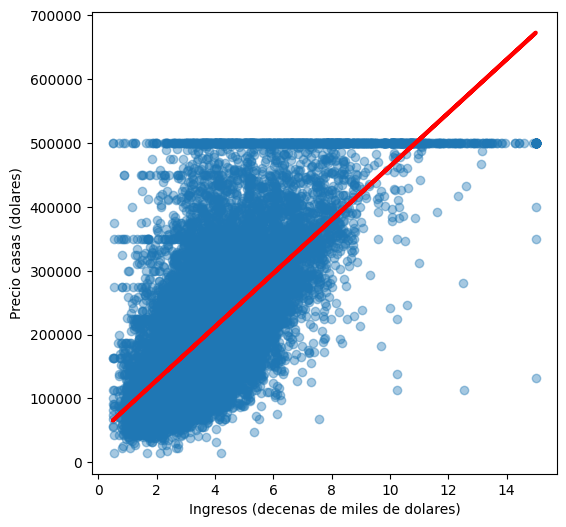

In [13]:
fig = plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.4)

#Representar la recta de regresion
y_pred = lm.predict(x)
plt.plot(x, y_pred, color='red', linewidth=3)

#Definir ejes
plt.xlabel("Ingresos (decenas de miles de dolares)")
plt.ylabel("Precio casas (dolares)")

#Mostrar grafico
plt.show()

Se observa que existe una correlación positiva entre ambas variables. No obstante,
el modelo de regresión lineal no parece ajustarse bien a la nube de puntos

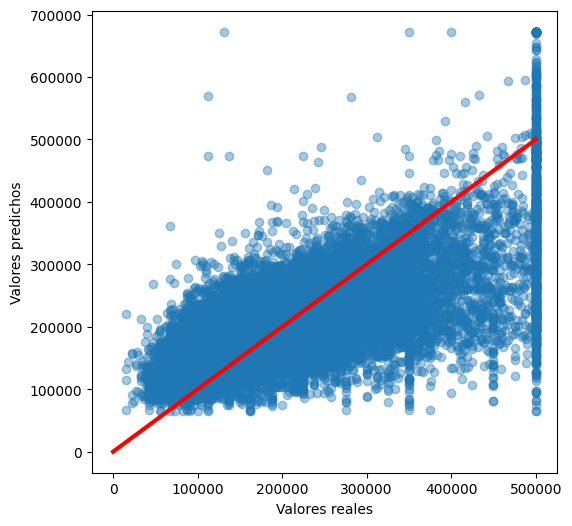

In [14]:
fig = plt.figure(figsize=(6,6))
plt.scatter(y, y_pred,alpha=0.4)
plt.plot([0, np.max(y)], [0, np.max(y)], color = 'red', linewidth = 3)

#Pintar recta de regresión
y_pred = lm.predict(x)
#Definir ejes
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")

#Mostrar grafico
plt.show()

In [16]:
#Cálculo de la varianza
y_resta = (y-y_pred)**2
varianza_MLS = np.sum(y_resta)/len(y)
print("La varianza por MLS es %s" %varianza_MLS)
#Estimador de la varianza por OLS
varianza_OLS = np.sum(y_resta)/(len(y)-2) #n-2
print("La varianza por OLS es %s" %varianza_OLS)

La varianza por MLS es 7011035574.262171
La varianza por OLS es 7011721887.76364


En este caso, al ser $n$ muy grande, no existe apenas diferencia entre ambos estimadores

## Ejercicio 3

Si en un nuevo barrio, sabemos que los ingresos medianos son 33700$, ¿Qué valor cabría esperar de la mediana del precio de las casas?

In [18]:
#Definimos el vector a predecir
nuevo_x = np.array([33700]).reshape(-1,1)

prediccion_x = lm.predict(nuevo_x)
print("El valor esperado de la casa es %s" %prediccion_x)

El valor esperado de la casa es [[1.40995403e+09]]


Fin 